<a href="https://colab.research.google.com/github/gyeong061/AIFFEL_QUEST_ENG/blob/main/DLthon_RAG_%ED%94%84%EB%A1%9C%EC%A0%9D%ED%8A%B8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 그림체 검색기 놀이터 — 고정 데이터로 검색 표현 개선하기

DLthon 그림체 RAG 팀용 실행 노트북입니다. 데이터는 `daypack_v2`로 고정하고,
**검색 표현만 바꿔 동일 조건에서 비교**합니다.

대표 지표는 **Style‑Macro mAP@5**입니다. P@5·Macro P@5·Lift와 속도/크기는
해석용 보조 지표로 함께 기록합니다.

## 1. 세팅 (5분)

In [ ]:
# 드라이브 연결
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import glob, os

# 현재 폴더명과 기존 프로젝트 폴더명을 모두 자동 인식한다.
FOLDER_NAMES = ["DLthon_RAG", "DLthon_그림체RAG"]
CANDS = []
for folder_name in FOLDER_NAMES:
    CANDS += glob.glob(f"/content/drive/MyDrive/{folder_name}")
    CANDS += glob.glob(f"/content/drive/MyDrive/*/{folder_name}")
    CANDS += glob.glob(f"/content/drive/Shareddrives/*/{folder_name}")

# 같은 경로가 여러 패턴에서 발견돼도 한 번만 남긴다.
CANDS = list(dict.fromkeys(CANDS))
if not CANDS:
    raise SystemExit(
        "DLthon_RAG 또는 DLthon_그림체RAG 폴더를 찾지 못했습니다.\n"
        "내 드라이브 바로 아래에 폴더를 두거나, 공유 폴더라면 "
        "'내 드라이브에 바로가기 추가' 후 이 셀을 다시 실행해 주세요."
    )

SHARE = CANDS[0]
print("프로젝트 폴더:", SHARE)
print("들어 있는 것:", sorted(os.path.basename(path) for path in glob.glob(SHARE + "/*")))

프로젝트 폴더: /content/drive/MyDrive/DLthon_RAG
들어 있는 것: ['DLthon_시작하기_MacroMap_실험추가.ipynb', 'daypack_v2.zip', 'kit_MacroMap_실험추가.zip', 'results']


In [ ]:
# 데이터와 도구를 코랩 로컬에 푼다. 수정 키트의 긴 파일명과 kit.zip을 모두 인식한다.
import shutil, time, zipfile

t0 = time.time()
archive_candidates = [
    (["daypack_v2.zip"], "데이터"),
    (["kit_MacroMap_실험추가.zip", "kit.zip"], "평가 키트"),
]


def extract_portable(zip_path, destination="/content"):
    # Windows(\)와 Linux(/) ZIP 경로를 모두 Linux 폴더 구조로 안전하게 푼다.
    destination = os.path.abspath(destination)
    with zipfile.ZipFile(zip_path) as archive:
        for member in archive.infolist():
            relative = member.filename.replace("\\", "/").lstrip("/")
            if not relative:
                continue
            target = os.path.abspath(os.path.join(destination, relative))
            if target != destination and not target.startswith(destination + os.sep):
                raise SystemExit(f"안전하지 않은 ZIP 경로입니다: {member.filename}")
            if member.is_dir() or relative.endswith("/"):
                os.makedirs(target, exist_ok=True)
            else:
                os.makedirs(os.path.dirname(target), exist_ok=True)
                with archive.open(member) as source_stream, open(target, "wb") as target_stream:
                    shutil.copyfileobj(source_stream, target_stream)

for names, label in archive_candidates:
    source = next(
        (os.path.join(SHARE, name) for name in names if os.path.exists(os.path.join(SHARE, name))),
        None,
    )
    if source is None:
        raise SystemExit(f"{label} 파일이 없습니다. 찾은 파일명 후보: {', '.join(names)}")
    extract_portable(source)
    print(f"  {os.path.basename(source)} 풀었습니다")

PACK = "/content/daypack_v2"
KIT = "/content/kit"
if not os.path.isdir(PACK) or not os.path.isdir(KIT):
    raise SystemExit("압축 내부에 daypack_v2/ 또는 kit/ 폴더가 없습니다. ZIP 구조를 확인하세요.")

image_patterns = ["*.jpg", "*.jpeg", "*.png", "*.webp"]
image_count = sum(
    len(glob.glob(os.path.join(PACK, "images", "*", pattern)))
    for pattern in image_patterns
)
style_count = len(glob.glob(os.path.join(PACK, "images", "*")))
print(f"\n그림 {image_count}장 / {style_count}클래스 ({time.time() - t0:.0f}초)")

  daypack_v2.zip 풀었습니다
  kit_MacroMap_실험추가.zip 풀었습니다

그림 2522장 / 20클래스 (6초)


In [ ]:
# 패키지 (코랩엔 torch·torchvision 이 이미 있다. transformers 만 확인)
!pip -q install "transformers>=4.40,<5" 2>&1 | tail -1
print("준비 끝")

gradio 6.20.0 requires huggingface-hub<2.0,>=1.2.0, but you have huggingface-hub 0.36.2 which is incompatible.
준비 끝


## 2. 먼저 판을 눈으로 봅니다

**숫자를 보기 전에 그림을 봅니다.** 뭘 구분하려는 건지 눈으로 알아야 방법이 떠오릅니다.

세 종류가 섞여 있습니다.

| 이름 | 무엇 | 난이도 |
|---|---|---|
| `ink_m1` ~ `ink_m9` | 흑백 회화 기법 9종 (연필선 ~ 짙은 먹) | **어렵다** — 색 단서가 없습니다 |
| `paint_*` | 서양화 사조 6종 (인상주의, 입체파 …) | 중간 |
| `vec_*` | 벡터 일러스트 5종 (이모지, unDraw …) | 쉽다 |

일부러 쉬운 것도 넣었습니다. 실제 서비스는 전 코퍼스에서 찾아야 하니까요.
대신 채점은 **클래스별·도메인별로 따로** 나옵니다.

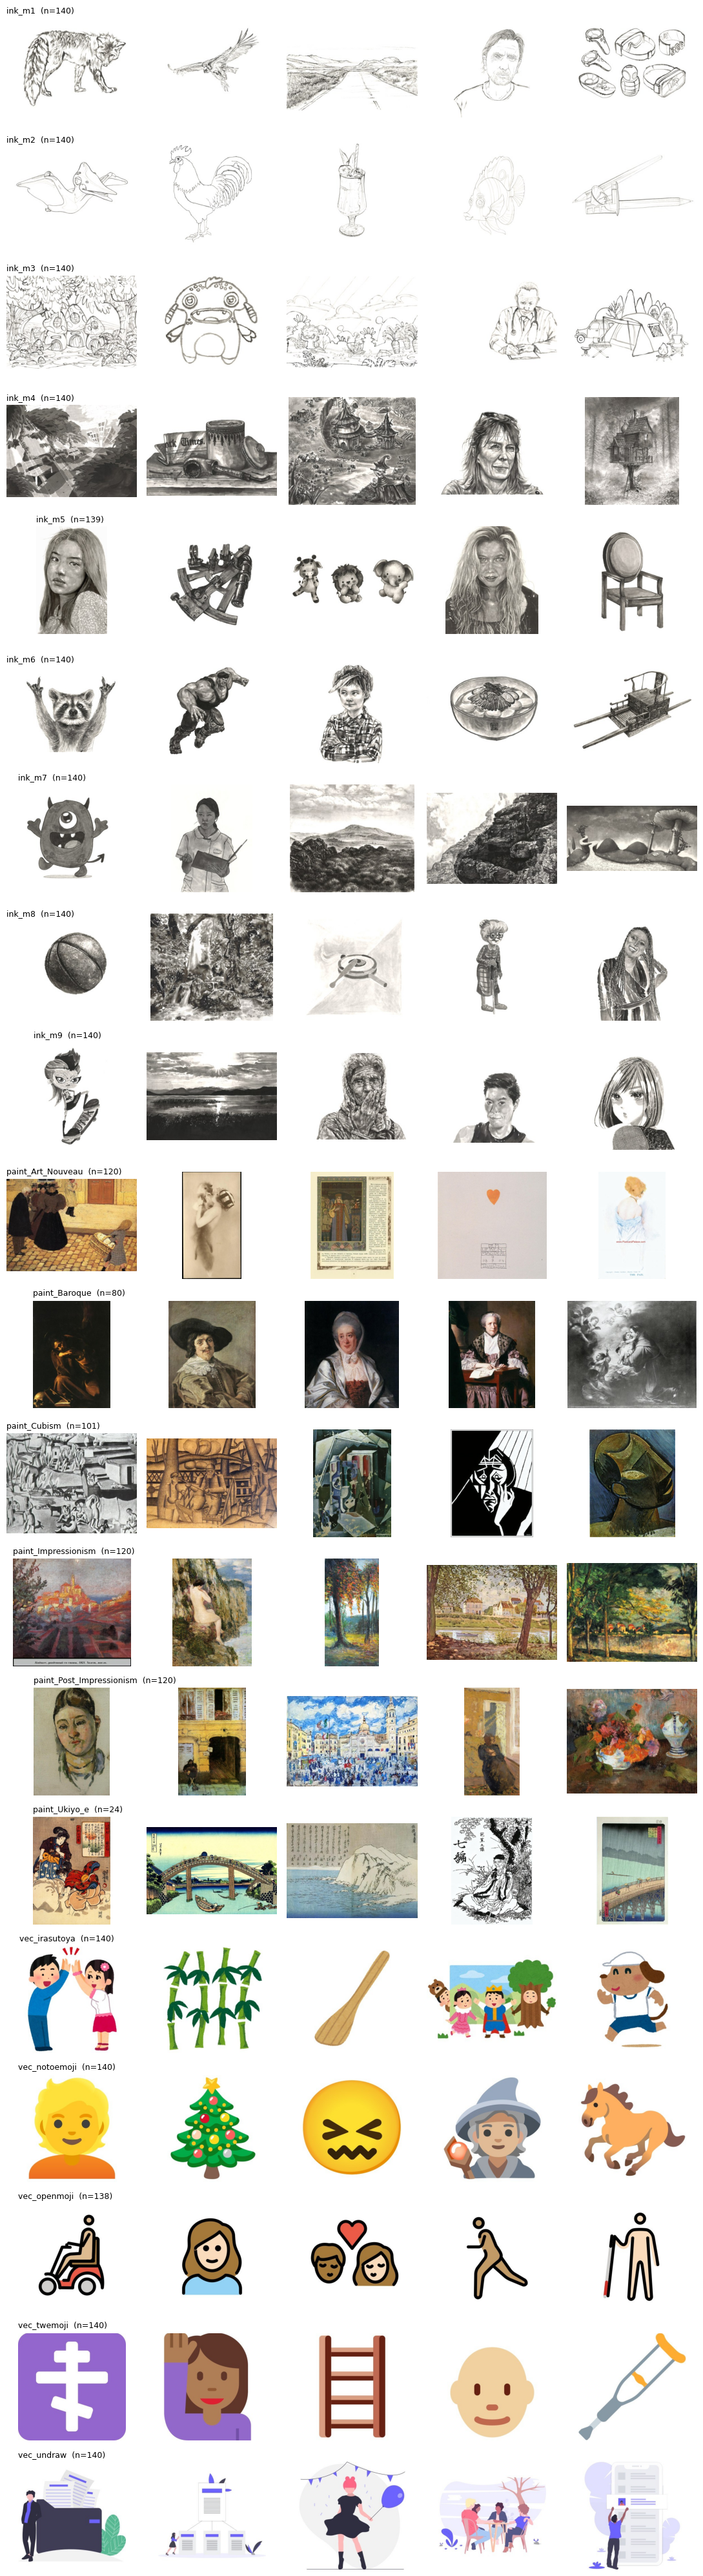

In [ ]:
import csv, collections, random
import matplotlib.pyplot as plt
from PIL import Image

rows = list(csv.DictReader(open(f'{PACK}/meta.csv', encoding='utf-8')))
by = collections.defaultdict(list)
for r in rows:
    by[r['style']].append(r['file'])

random.seed(0)
ks = sorted(by)
fig, axes = plt.subplots(len(ks), 5, figsize=(11, 2.0 * len(ks)))
for i, k in enumerate(ks):
    for j, f in enumerate(random.sample(by[k], 5)):
        ax = axes[i][j]
        ax.imshow(Image.open(f'{PACK}/{f}'))
        ax.axis('off')
        if j == 0:
            ax.set_title(f'{k}  (n={len(by[k])})', fontsize=9, loc='left')
plt.tight_layout(); plt.show()

### 잠깐 — 여기서 감을 잡고 갑니다

`ink_m4` ~ `ink_m8` 을 비교해 보세요. **사람 눈에도 애매합니다.** 그게 이 판이 어려운 이유입니다.
반대로 `vec_*` 는 한눈에 갈립니다.

그리고 하나 더. 같은 `ink` 안에는 **똑같은 그림을 다른 기법으로 그린 짝**이 들어 있습니다.
이게 함정입니다 — 검색기가 "그림체가 같은 것"이 아니라 **"내용이 같은 것"** 을 찾아와도 점수가 오릅니다.

실측으로 그 차이가 이렇습니다.

| 가장 가까운 5장에 오는 것 | 무작위 대비 |
|---|---|
| 같은 **내용** (같은 그림, 다른 기법) | **102배** |
| 같은 **그림체** (다른 그림, 같은 기법) | **1.5배** |

즉 그냥 재면 그림체가 아니라 내용을 재게 됩니다.
**그래서 채점기가 "자기 자신"과 "같은 원본/같은 작가"를 이웃 후보에서 빼고 잽니다.** 신경 안 쓰셔도 됩니다.

## 3. 기준선 돌려서 첫 점수 (3분)

먼저 **CLIP 임베딩을 그대로** 쓴 것입니다. 이게 출발점이고, 여러분이 이겨야 할 선입니다.

In [ ]:
%cd /content/kit
!DAYPACK=/content/daypack_v2 python score.py encoders/clip_base.py --name "CLIP 기준선(내 실행)"

/content/kit
[1] 코퍼스 daypack_v2 - 2522장 / 20클래스
    평가 프로토콜: style-retrieval-v3_group-excluded_vector-emoji-v1
    코퍼스 지문: aebc56db593a6829
    group 출처: {np.str_('metadata'): 1824, np.str_('missing'): 280, np.str_('derived_vector_emoji'): 418}
2026-07-30 06:52:47.359192: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
config.json: 4.19kB [00:00, 12.4MB/s]
pytorch_model.bin: 100% 605M/605M [00:04<00:00, 138MB/s]
model.safetensors:   0% 0.00/605M [00:00<?, ?B/s]Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow 

### 점수 읽는 법

1. **Style‑Macro mAP@5 (대표 지표)**: 질의별 검색 순서를 AP@5로 채점하고,
   각 스타일의 평균을 구한 뒤 20개 스타일에 같은 가중치를 줍니다. 좋은 레퍼런스를
   앞 순위에 놓을수록 높습니다.
2. **P@5 / Macro P@5 (보조 지표)**: Top 5에서 같은 스타일이 차지하는 비율입니다.
   Macro 값은 스타일별 데이터 수 차이를 보정합니다.
3. **도메인 내부 지표**: ink·paint·vector 안에서만 후보를 검색해 어느 영역이
   실제로 개선됐는지 확인합니다.
4. **차원·인덱스 크기·인코딩/검색 시간**: 점수 상승에 필요한 비용을 보여줍니다.

`95% 구간`은 모델을 반복 실행했을 때의 흔들림이 아니라, 현재 평가 질의 표본에 대한
불확실성입니다.

## 4. 두 번째 기준선 — Gram (선택, 2~3분 더)

**내용을 버리고 "어떻게 칠했나"만 남기는** 방법입니다.
VGG 중간층에서 채널끼리 내적하면 위치 정보(H, W)가 사라지고 붓결·질감만 남습니다.

지금 리더보드 1등이지만 **약점이 있습니다.** 돌려보고 도메인 표를 비교해 보세요.

In [ ]:
!DAYPACK=/content/daypack_v2 python score.py encoders/gram_vgg19.py --name "Gram VGG19(내 실행)"

[1] 코퍼스 daypack_v2 - 2522장 / 20클래스
    평가 프로토콜: style-retrieval-v3_group-excluded_vector-emoji-v1
    코퍼스 지문: aebc56db593a6829
    group 출처: {np.str_('metadata'): 1824, np.str_('missing'): 280, np.str_('derived_vector_emoji'): 418}
Downloading: "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth" to /root/.cache/torch/hub/checkpoints/vgg19-dcbb9e9d.pth
100% 548M/548M [00:06<00:00, 89.2MB/s]
[2] Gram VGG19(내 실행)로 임베딩 생성 중
    2522x174560 (38.2초, float32 1761.0MB)
[3] 전체 코퍼스에서 Top-5 채점 중

스타일                           P@5     AP@5      무작위    Lift
ink_m1                     0.4914   0.3744   0.0551    8.91
ink_m2                     0.5586   0.4713   0.0551   10.13
ink_m3                     0.5571   0.4685   0.0551   10.10
ink_m4                     0.2214   0.1437   0.0551    4.02
ink_m5                     0.2691   0.1753   0.0547    4.91
ink_m6                     0.2714   0.1782   0.0551    4.92
ink_m7                     0.2343   0.1494   0.0551    4.25
ink_m8                  

### ★ 아직 안 풀린 지점

기존 실험에서 CLIP과 Gram의 승자가 도메인마다 달랐습니다.

| 도메인 | CLIP | Gram | 관찰 |
|---|---:|---:|---|
| ink | 0.2262 | **0.3595** | 질감 표현이 유리 |
| paint | **0.5324** | 0.3706 | 색·구도/내용 표현이 유리 |
| vector | 0.6510 | **0.8481** | 단순한 표면 패턴이 유리 |

따라서 목표를 “표현 하나를 무조건 선택”하는 대신, **CLIP의 의미·구도 정보와
Gram의 질감 정보를 결합해 전체 Style‑Macro mAP@5를 높이는 것**으로 잡습니다.
특히 paint가 개선됐는지는 도메인 내부 표에서 별도로 확인합니다.

## 5. ★ 고정 데이터에서 새롭게 진행할 실험

데이터를 늘리거나 바꾸지 않습니다. 동일한 `daypack_v2`에서 **표현 방식과 결합
가중치만 변경**합니다. 아래 순서대로 실행하면 원인 분석이 가능한 ablation 표가 됩니다.

### 5-1. 저층 Gram — 질감 정보만 가볍게

전체 Gram의 4개 층 대신 `relu1_1`, `relu2_1`만 사용합니다. 차원은
174,560 → 10,336으로 줄어듭니다. 점수뿐 아니라 인덱스 크기와 검색 시간도 비교하세요.

In [ ]:
!DAYPACK=/content/daypack_v2 python score.py encoders/gram_low_vgg19.py \
    --name "저층 Gram" --note "relu1_1+relu2_1"

[1] 코퍼스 daypack_v2 - 2522장 / 20클래스
    평가 프로토콜: style-retrieval-v3_group-excluded_vector-emoji-v1
    코퍼스 지문: aebc56db593a6829
    group 출처: {np.str_('metadata'): 1824, np.str_('missing'): 280, np.str_('derived_vector_emoji'): 418}
[2] 저층 Gram로 임베딩 생성 중
    2522x10336 (22.4초, float32 104.3MB)
[3] 전체 코퍼스에서 Top-5 채점 중

스타일                           P@5     AP@5      무작위    Lift
ink_m1                     0.4500   0.3444   0.0551    8.16
ink_m2                     0.4571   0.3562   0.0551    8.29
ink_m3                     0.3914   0.2960   0.0551    7.10
ink_m4                     0.2200   0.1356   0.0551    3.99
ink_m5                     0.2187   0.1270   0.0547    3.99
ink_m6                     0.2200   0.1354   0.0551    3.99
ink_m7                     0.2086   0.1181   0.0551    3.78
ink_m8                     0.3414   0.2362   0.0551    6.19
ink_m9                     0.2357   0.1497   0.0551    4.27
paint_Art_Nouveau          0.1650   0.0959   0.0451    3.66
paint_Baroque        

### 5-2. CLIP + 저층 Gram — 핵심 결합 실험

각 특징을 따로 정규화한 뒤 가중 코사인 유사도로 합칩니다. 아래 세 값은 각각
CLIP 비중 25%, 50%, 75%입니다. 세 실험 중 대표 점수가 가장 높은 가중치를 고릅니다.
가중치를 이 세 개만 먼저 보는 이유는 작은 평가셋에 과적합하지 않으면서 방향을
빠르게 확인하기 위해서입니다. 첫 실행에서 CLIP·저층 Gram 특징을 캐시에 저장하므로
두 번째와 세 번째 실행은 인코딩을 다시 하지 않습니다.

In [ ]:
!CLIP_WEIGHT=0.25 DAYPACK=/content/daypack_v2 python score.py encoders/clip_lowgram.py \
    --name "CLIP+저층Gram w0.25" --note "CLIP 0.25 / Gram 0.75"
!CLIP_WEIGHT=0.50 DAYPACK=/content/daypack_v2 python score.py encoders/clip_lowgram.py \
    --name "CLIP+저층Gram w0.50" --note "CLIP 0.50 / Gram 0.50"
!CLIP_WEIGHT=0.75 DAYPACK=/content/daypack_v2 python score.py encoders/clip_lowgram.py \
    --name "CLIP+저층Gram w0.75" --note "CLIP 0.75 / Gram 0.25"

[1] 코퍼스 daypack_v2 - 2522장 / 20클래스
    평가 프로토콜: style-retrieval-v3_group-excluded_vector-emoji-v1
    코퍼스 지문: aebc56db593a6829
    group 출처: {np.str_('metadata'): 1824, np.str_('missing'): 280, np.str_('derived_vector_emoji'): 418}
[2] CLIP+저층Gram w0.25로 임베딩 생성 중
2026-07-30 06:55:27.369413: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.
    [cache] clip_base: clip_base.npy 저장
    [cache] gram_low_vgg19: gram_low_vgg19.npy 저장
  

### 5-3. HSV 색 분포 추가 — paint 보완 가설 확인

회화는 붓결뿐 아니라 색으로도 구분될 수 있다는 가설을 확인합니다. HSV는 48차원만
추가하며 기본 가중치는 CLIP 0.45 / Gram 0.45 / HSV 0.10입니다.

이 실험이 전체 대표 점수와 `paint` 내부 점수를 함께 올릴 때만 채택합니다. paint만
오르고 전체가 떨어지면 도메인별 방법 선택을 후속 실험으로 남깁니다.

In [ ]:
!CLIP_WEIGHT=0.45 GRAM_WEIGHT=0.45 HSV_WEIGHT=0.10 \
    DAYPACK=/content/daypack_v2 python score.py encoders/clip_lowgram_hsv.py \
    --name "CLIP+저층Gram+HSV" --note "0.45 / 0.45 / 0.10"

[1] 코퍼스 daypack_v2 - 2522장 / 20클래스
    평가 프로토콜: style-retrieval-v3_group-excluded_vector-emoji-v1
    코퍼스 지문: aebc56db593a6829
    group 출처: {np.str_('metadata'): 1824, np.str_('missing'): 280, np.str_('derived_vector_emoji'): 418}
[2] CLIP+저층Gram+HSV로 임베딩 생성 중
    [cache] clip_base: clip_base.npy 재사용
    [cache] gram_low_vgg19: gram_low_vgg19.npy 재사용
    [cache] hsv_histogram: hsv_histogram.npy 저장
    2522x10896 (21.7초, float32 109.9MB)
[3] 전체 코퍼스에서 Top-5 채점 중

스타일                           P@5     AP@5      무작위    Lift
ink_m1                     0.3243   0.2273   0.0551    5.88
ink_m2                     0.3543   0.2552   0.0551    6.42
ink_m3                     0.4143   0.3240   0.0551    7.51
ink_m4                     0.2014   0.1106   0.0551    3.65
ink_m5                     0.1885   0.1165   0.0547    3.44
ink_m6                     0.1957   0.1184   0.0551    3.55
ink_m7                     0.1957   0.1143   0.0551    3.55
ink_m8                     0.2714   0.1792   0.0551  

### 실험 선택 기준

1. `Style‑Macro mAP@5`가 기준선보다 높은가?
2. 대응 비교의 95% 구간이 0보다 큰가?
3. paint를 살리면서 ink/vector가 크게 무너지지 않는가?
4. 점수 상승에 비해 차원·인덱스·시간 비용이 감당 가능한가?

대표 점수가 비슷하면 더 작은 차원과 더 짧은 지연시간을 가진 방법을 선택합니다.

## 6. 이겼는지 대응 비교하기

평균 숫자만 보지 않고 동일 질의의 AP@5 차이를 짝지어 비교합니다. 기본값은
Style‑Macro mAP@5 비교입니다. 아래 이름은 실제 실행한 이름과 정확히 같아야 합니다.

In [ ]:
!python compare.py "CLIP 기준선(내 실행)" "저층 Gram"
!python compare.py "CLIP 기준선(내 실행)" "CLIP+저층Gram w0.50"
!python compare.py "CLIP+저층Gram w0.50" "CLIP+저층Gram+HSV"


비교 지표: Style-Macro ap5
평가 프로토콜: style-retrieval-v3_group-excluded_vector-emoji-v1
코퍼스 지문: aebc56db593a6829
A  CLIP 기준선(내 실행)               0.3542 (질의 평균 0.3211)
B  저층 Gram                      0.3235 (질의 평균 0.3386)

차이 (B - A)             -0.0307
대응 차이의 95% 구간     -0.0440 ~ -0.0174
질의별 승패               B승 1149 / A승 923 / 무 450

판정: A가 이겼습니다. 구간 전체가 0보다 작습니다.

비교 지표: Style-Macro ap5
평가 프로토콜: style-retrieval-v3_group-excluded_vector-emoji-v1
코퍼스 지문: aebc56db593a6829
A  CLIP 기준선(내 실행)               0.3542 (질의 평균 0.3211)
B  CLIP+저층Gram w0.50            0.3864 (질의 평균 0.3601)

차이 (B - A)             +0.0322
대응 차이의 95% 구간     +0.0249 ~ +0.0395
질의별 승패               B승 1033 / A승 618 / 무 871

판정: B가 이겼습니다. 구간 전체가 0보다 큽니다.

비교 지표: Style-Macro ap5
평가 프로토콜: style-retrieval-v3_group-excluded_vector-emoji-v1
코퍼스 지문: aebc56db593a6829
A  CLIP+저층Gram w0.50            0.3864 (질의 평균 0.3601)
B  CLIP+저층Gram+HSV              0.3885 (질의 평균 0.3658)

차이 (B - A)             +0.0021
대응 차이의 95% 구간     -0.0035 ~ +

`차이의 95% 구간` 전체가 0보다 크면 B가 우세합니다. 0을 포함하면 현재 평가셋으로는
승자를 확정하지 않습니다. 최종 가중치 결정에는 테스트셋을 사용하지 말고, 가능하면
고정된 검증 분할에서 고른 뒤 테스트셋은 마지막 한 번만 확인하세요.

## 7. 결과 공유

리더보드, 요약 JSON, 질의별 AP@5가 든 NPZ를 공유 폴더로 복사합니다. NPZ가 있어야
다른 팀원의 실행 결과와 대응 비교할 수 있습니다.

In [ ]:
import glob, os, shutil

MY_NAME = "김수경"  # 자기 이름으로 변경
destination = os.path.join(SHARE, "results", MY_NAME)
os.makedirs(destination, exist_ok=True)

for pattern in [
    "/content/kit/leaderboard.csv",
    "/content/kit/runs/*.json",
    "/content/kit/runs/*.npz",
    "/content/kit/runs/*_cases.csv",
    "/content/kit/runs/*_per_style.csv"
]:
    for path in glob.glob(pattern):
        shutil.copy2(path, destination)

print("저장 완료:", destination)

저장 완료: /content/drive/MyDrive/DLthon_RAG/results/김수경


---

## 해석 시 주의

- Macro mAP@5는 **검색된 레퍼런스의 순위 품질**을 평가합니다.
- 생성 이미지의 그림체 반영, 장면 내용, 4컷 일관성, 캐릭터 일관성은 생성 모델을
  연결한 뒤 별도의 평가 단계에서 측정해야 합니다.
- 지금 단계의 최종 산출물은 “어떤 검색 표현이 고정 데이터에서 좋은 레퍼런스를
  앞쪽에 가져오는가”에 대한 근거입니다.